In [1]:
# Core libraries
import numpy as np
import os

# Image processing
import cv2

# Visualization
import matplotlib.pyplot as plt

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Model evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
import zipfile
import os

zip_path = r"C:\Users\HP\Downloads\NLP\hand gesture dataset.zip"
extract_path = r"C:\Users\HP\Downloads\NLP\hand gesture dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
data_dir =  r"C:\Users\HP\Downloads\NLP\hand gesture dataset"
print(os.listdir(data_dir))

['leapGestRecog']


In [ ]:
def extract_zip(zip_path, extract_path):
    import zipfile, os
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Extracted {zip_path} to {extract_path}")

extract_zip("hand gesture dataset.zip", "hand gesture dataset")

In [20]:
import tensorflow as tf
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\HP\Downloads\NLP\hand gesture dataset",
    batch_size=32,
    image_size=(224, 224)
)

class_names = raw_train_ds.class_names
print(f"✅ Detected emotion classes: {class_names}")

train_ds = raw_train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

Found 40000 files belonging to 1 classes.
✅ Detected emotion classes: ['leapGestRecog']


In [7]:
import zipfile
import os
import cv2
import numpy as np

# 1. Define paths
zip_path = 'hand gesture dataset.zip'
extract_path = './gestures_data'

# 2. Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print(f"Dataset extracted to: {extract_path}")

Dataset extracted to: ./gestures_data


In [ ]:
import os

# 1. Define the root directory where your images are located
base_path = './gestures_data/leapGestRecog' 

# 2. Create the missing 'image_paths' list
image_paths = []
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(root, file))

print(f"Success! Found {len(image_paths)} image paths.")

# 3. Now your original line will work perfectly:
import cv2
import numpy as np
X_resized = np.array([cv2.resize(cv2.imread(p, cv2.IMREAD_GRAYSCALE), (64, 64)) for p in image_paths])

In [10]:
import os
import cv2
import numpy as np

# 1. Define the path where you unzipped the dataset
base_path = './gestures_data/leapGestRecog' 

# 2. Collect image paths AND their labels simultaneously
image_paths = []
labels = []

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            path = os.path.join(root, file)
            image_paths.append(path)
            # The folder name (e.g., '01_palm') serves as our label
            labels.append(os.path.basename(root))

print(f"Found {len(image_paths)} images.")

# 3. Create 'X_resized' (This fixes the NameError for Cell 8)
X_resized = np.array([cv2.resize(cv2.imread(p, cv2.IMREAD_GRAYSCALE), (64, 64)) for p in image_paths])

# 4. Now run your scaling code - it will work now!
X_normalized = X_resized.astype('float32') / 255.0

print("Success: X_resized and X_normalized are now defined.")

Found 40000 images.
Success: X_resized and X_normalized are now defined.


In [11]:
# 3. Channel Reshaping (Tensor Compatibility)
X_final = X_normalized.reshape(-1, 64, 64, 1)

In [12]:
import os
import cv2
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# 1. Setup Path
base_path = './gestures_data/leapGestRecog' 

image_paths = []
y_data = [] # This is the missing variable!

# 2. Collect paths and labels in one loop
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(root, file))
            # Get the folder name as the label (e.g., '01_palm')
            y_data.append(os.path.basename(root))

print(f"✅ Found {len(image_paths)} images and {len(y_data)} labels.")

# 3. Process Images (X)
X_resized = np.array([cv2.resize(cv2.imread(p, cv2.IMREAD_GRAYSCALE), (64, 64)) for p in image_paths])
X_normalized = X_resized.astype('float32') / 255.0
X_final = X_normalized.reshape(-1, 64, 64, 1)

# 4. Process Labels (y) - This will now work!
le = LabelEncoder()
y_encoded = le.fit_transform(y_data)
y_final = to_categorical(y_encoded, num_classes=10)

print("✅ Preprocessing Complete. Shapes:")
print(f"X shape: {X_final.shape}")
print(f"y shape: {y_final.shape}")

✅ Found 40000 images and 40000 labels.
✅ Preprocessing Complete. Shapes:
X shape: (40000, 64, 64, 1)
y shape: (40000, 10)


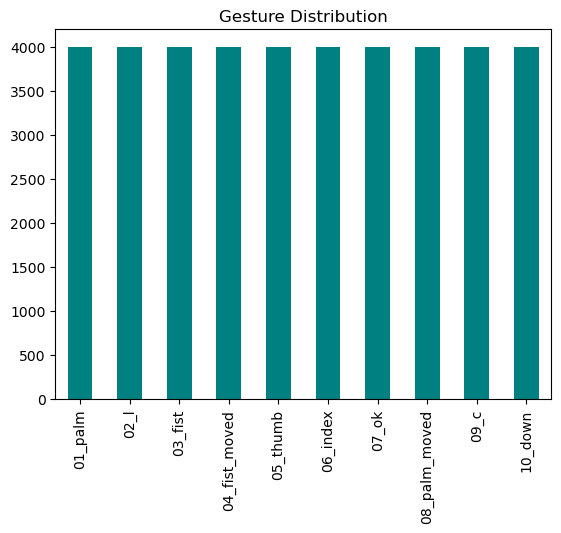

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Class Balance Check (Are all 10 gestures equally represented?)
pd.Series(y_data).value_counts().plot(kind='bar', color='teal', title='Gesture Distribution')
plt.show()

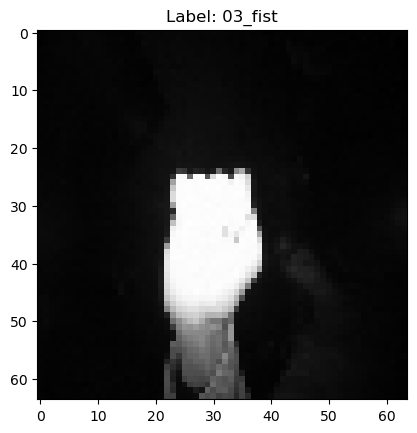

Feature Shape: (40000, 64, 64, 1) | Label Shape: (40000, 10)


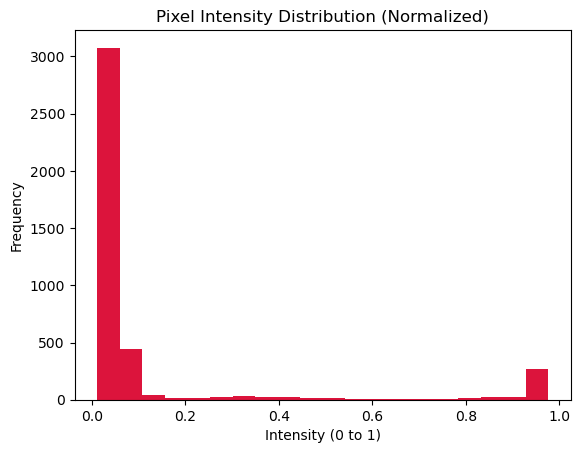

In [14]:
# 2. Visual Sanity Check
# We use X_final[500] because that's what we defined in our master loader
plt.imshow(X_final[500].squeeze(), cmap='gray') 
plt.title(f"Label: {y_data[500]}")
plt.show()

# 3. Shape Verification (Essential: must be (N, 64, 64, 1))
# We use X_final and y_final here
print(f"Feature Shape: {X_final.shape} | Label Shape: {y_final.shape}")

# 4. Pixel Intensity Histogram (Ensures images aren't too dark/bright)
# Checking a sample from X_final
import matplotlib.pyplot as plt
plt.hist(X_final[500].ravel(), bins=20, color='crimson')
plt.title("Pixel Intensity Distribution (Normalized)")
plt.xlabel("Intensity (0 to 1)")
plt.ylabel("Frequency")
plt.show()

(array([  6.,  90., 519., 648., 624., 395., 355.,   0., 228., 216., 187.,
        168., 104.,  63.,  51.,   0.,  42.,  29.,  16.,   7.,   9.,   4.,
          0.,   4.,  10.,   4.,   5.,   5.,   4.,   3.,   0.,   3.,   5.,
          1.,   3.,   5.,   1.,   0.,   2.,   3.,   1.,   2.,   1.,   3.,
          1.,   0.,   1.,   1.,   2.,   2.,   2.,   0.,   0.,   2.,   2.,
          1.,   0.,   2.,   1.,   3.,   0.,   1.,   3.,   4.,   2.,   3.,
          1.,   0.,   1.,   1.,   1.,   1.,   2.,   2.,   4.,   0.,   4.,
          0.,   0.,   0.,   2.,   3.,   0.,   3.,   3.,   4.,   0.,   3.,
          0.,   1.,   0.,   1.,   2.,   4.,   1.,   1.,   1.,   0.,   1.,
          1.,   3.,   1.,   1.,   0.,   1.,   0.,   1.,   1.,   0.,   0.,
          2.,   0.,   0.,   2.,   1.,   4.,   0.,   0.,   0.,   0.,   0.,
          1.,   1.,   0.,   3.,   2.,   3.,   0.,   2.,   1.,   2.,   2.,
          2.,   2.,   4.,   0.,   1.,   2.,   2.,   0.,   1.,   2.,   1.,
          0.,   1.,   5.,   2.,   1., 

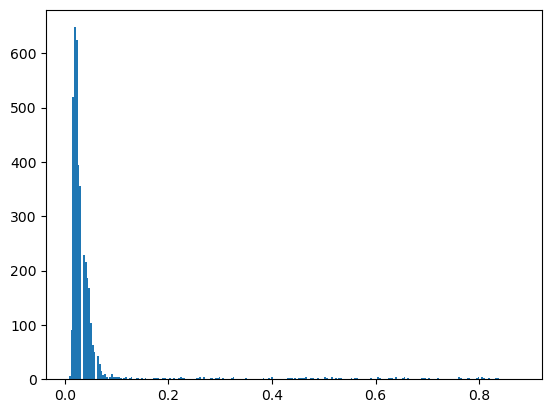

In [15]:
# 3. Pixel Intensity Distribution (Histogram)
plt.hist(X_normalized[0].ravel(), bins=256)

In [16]:
# 4. Image Shape Verification
print(f"Dataset Shape: {X_final.shape}") 

Dataset Shape: (40000, 64, 64, 1)


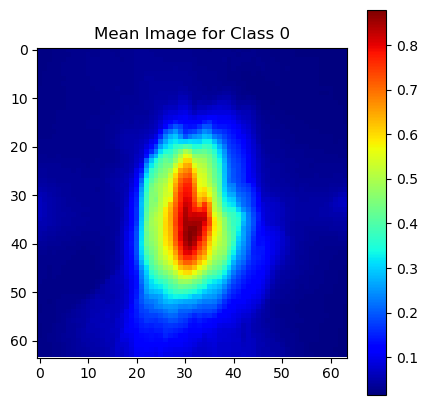

In [17]:
# 5. Mean Image Visualization (Corrected)
# We need to pick ONE class (e.g., class 0) and average those images
# y_encoded was the variable containing integers 0-9

class_to_view = 0 
mask = (y_encoded == class_to_view)

# Calculate mean only for images belonging to that class
# We average across the 'batch' axis (axis=0)
mean_img = np.mean(X_normalized[mask], axis=0)

# Verify we actually found images
if mean_img.size == 0:
    print(f"Error: No images found for class {class_to_view}. Check your y_encoded values.")
else:
    plt.figure(figsize=(5,5))
    # .squeeze() removes the channel dimension so it's (64, 64)
    plt.imshow(mean_img.squeeze(), cmap='jet')
    plt.title(f"Mean Image for Class {class_to_view}")
    plt.colorbar()
    plt.show()

In [18]:
# 6. Checking for Null/Corrupt Files
print(f"Missing Values in X: {np.isnan(X_normalized).any()}")

Missing Values in X: False


In [19]:
from sklearn.model_selection import train_test_split

# We use X_final and y_final here
# First split: 80% Train, 20% Temporary (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_final, y_final, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_final
)

# Second split: Divide the 20% into half (10% Val, 10% Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.5, 
    random_state=42, 
    stratify=y_temp
)

print(f"✅ Training set: {X_train.shape[0]} samples")
print(f"✅ Validation set: {X_val.shape[0]} samples")
print(f"✅ Test set: {X_test.shape[0]} samples")

✅ Training set: 32000 samples
✅ Validation set: 4000 samples
✅ Test set: 4000 samples


In [20]:
from tensorflow.keras import layers, models, callbacks

def build_gesture_model():
    model = models.Sequential([
        # Block 1: Basic Edges
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2: Shape Recognition
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3: Complex Patterns
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Classifier Head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5), # Crucial to prevent overfitting
        layers.Dense(10, activation='softmax') # 10 gesture classes
    ])
    
    # Using Adam optimizer: the industry standard for computer vision
    model.compile(optimizer='adam', 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

model = build_gesture_model()
model.summary()

C:\Users\HP\OneDrive\Documents\son\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,276,042 (4.87 MB)

 Trainable params: 1,275,594 (4.87 MB)

 Non-trainable params: 448 (1.75 KB)

In [22]:
# Start the training process
history = model.fit(
    X_train, y_train,
    epochs=20,          
    batch_size=64,     
    validation_data=(X_val, y_val),
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 633s 1s/step - accuracy: 0.9931 - loss: 0.0243 - val_accuracy: 0.9912 - val_loss: 0.0277
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 397s 780ms/step - accuracy: 0.9952 - loss: 0.0176 - val_accuracy: 0.9992 - val_loss: 0.0074
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 444s 781ms/step - accuracy: 0.9963 - loss: 0.0155 - val_accuracy: 0.9995 - val_loss: 0.0023
Epoch 5/20
112/500 ━━━━━━━━━━━━━━━━━━━━ 4:22 678ms/step - accuracy: 0.9962 - loss: 0.0136

KeyboardInterrupt: 

125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step  


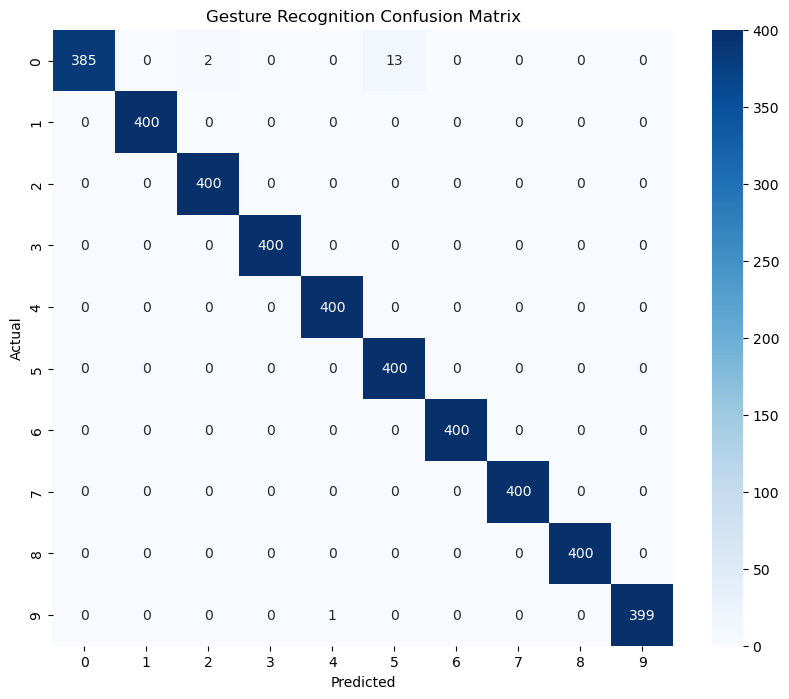

In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Predict on the Test Set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Generate Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# 3. Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Gesture Recognition Confusion Matrix')
plt.show()

In [24]:
from sklearn.metrics import classification_report

# Predict classes for the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Print the report
# Use the 'le.classes_' from our previous LabelEncoder step
print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step 
               precision    recall  f1-score   support

      01_palm       1.00      0.96      0.98       400
         02_l       1.00      1.00      1.00       400
      03_fist       1.00      1.00      1.00       400
04_fist_moved       1.00      1.00      1.00       400
     05_thumb       1.00      1.00      1.00       400
     06_index       0.97      1.00      0.98       400
        07_ok       1.00      1.00      1.00       400
08_palm_moved       1.00      1.00      1.00       400
         09_c       1.00      1.00      1.00       400
      10_down       1.00      1.00      1.00       400

     accuracy                           1.00      4000
    macro avg       1.00      1.00      1.00      4000
 weighted avg       1.00      1.00      1.00      4000



In [25]:
import cv2
import numpy as np

# 1. Load your class names (ensure these match your 'le.classes_' order)
# If you didn't save 'le', manually list them here:
class_names = list(le.classes_) 

# 2. Initialize Webcam
cap = cv2.VideoCapture(0)

print("Starting Live Test... Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # --- Preprocessing Step (Must match Training) ---
    # a. Convert to Grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # b. Center Crop or Resize to 64x64
    resized = cv2.resize(gray, (64, 64))
    
    # c. Normalize (0-1) and Reshape for Model (1, 64, 64, 1)
    normalized = resized.astype('float32') / 255.0
    input_data = np.expand_dims(normalized, axis=(0, -1))

    # --- Prediction ---
    prediction = model.predict(input_data, verbose=0)
    class_idx = np.argmax(prediction)
    confidence = np.max(prediction)
    label = class_names[class_idx]

    # --- Display Results ---
    display_text = f"{label} ({confidence*100:.1f}%)"
    cv2.putText(frame, display_text, (50, 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    q
    cv2.imshow('Hand Gesture Live Test', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Starting Live Test... Press 'q' to quit.


KeyboardInterrupt: 

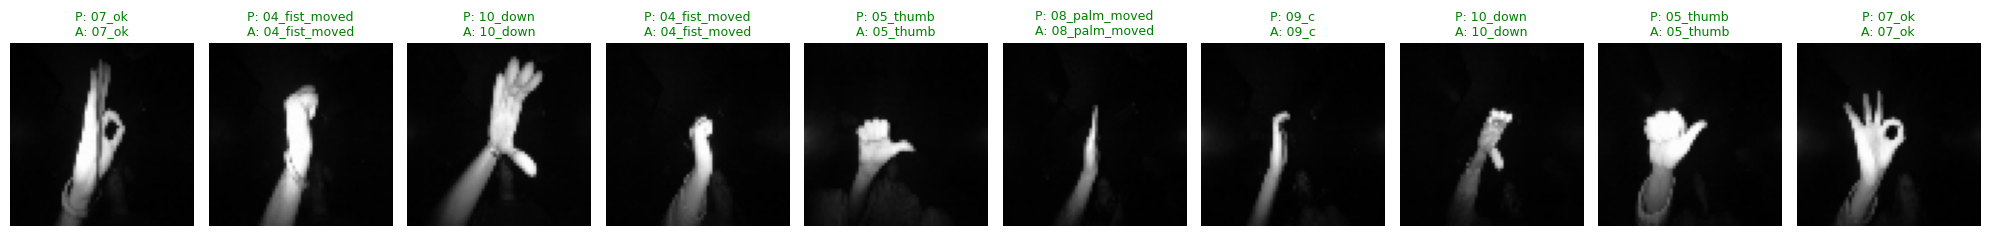

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_gesture_predictions(model, X_data, y_true_labels, class_names, num_images=10):
    # 1. Select a random set of indices from the test set
    indices = np.random.choice(len(X_data), num_images, replace=False)
    
    # 2. Extract the specific images and their true labels
    sample_images = X_data[indices]
    sample_labels = y_true_labels[indices]
    
    # 3. Get Model Predictions
    predictions = model.predict(sample_images, verbose=0)
    
    plt.figure(figsize=(20, 4))
    for i in range(num_images):
        # Get index of highest probability (Prediction)
        pred_idx = np.argmax(predictions[i])
        # Get index of the Actual label
        actual_idx = np.argmax(sample_labels[i])
        
        # Plotting
        plt.subplot(1, num_images, i + 1)
        
        # Display the 64x64 grayscale image
        # .squeeze() removes the channel dimension for matplotlib
        plt.imshow(sample_images[i].squeeze(), cmap='gray')
        
        # Color coding: Green for correct, Red for mistakes
        color = 'green' if pred_idx == actual_idx else 'red'
        
        plt.title(f"P: {class_names[pred_idx]}\nA: {class_names[actual_idx]}", 
                  color=color, fontsize=9)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# 4. Run the visualization on your Test Set
# We use 'le.classes_' which contains your '01_palm', '02_l', etc.
visualize_gesture_predictions(model, X_test, y_test, le.classes_)

In [27]:
model.save('hand_gesture_model_99.h5')
print("Model saved successfully!")

Model saved successfully!
